# 💳 Project 2: Supervised Learning — Fraud Detection Pipeline
### Credit Card Fraud Dataset | DecodeLabs Industrial Training — Batch 2026

---

**Goal:** Build a leak-free classification pipeline that detects fraudulent transactions in a highly imbalanced dataset.

**Pipeline Overview:**
1. 📦 Data Loading & Class Imbalance Analysis
2. ⚠️ Why Accuracy is a Trap (Confusion Matrix Explained)
3. ✂️ Stratified Train/Test Split
4. 🔁 Pipeline 1 — Logistic Regression + StandardScaler + SMOTE
5. 🌲 Pipeline 2 — Random Forest + SMOTE (no scaler needed)
6. 🔍 GridSearchCV Hyperparameter Tuning
7. 📊 Evaluation — Precision, Recall, ROC-AUC (Never Accuracy)
8. 📈 ROC Curve Comparison
9. ✅ Final Model Selection & Summary


## Download the Dataset from this link
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

## 📦 Step 0: Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_score, recall_score, f1_score)

# Imbalanced-learn (imblearn) — REQUIRED for leak-free SMOTE in pipelines
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("✅ All libraries imported successfully!")
print("NOTE: We use imblearn.pipeline.Pipeline — NOT sklearn.pipeline.Pipeline")
print("      imblearn's Pipeline natively supports fit_resample() for SMOTE.")


✅ All libraries imported successfully!
NOTE: We use imblearn.pipeline.Pipeline — NOT sklearn.pipeline.Pipeline
      imblearn's Pipeline natively supports fit_resample() for SMOTE.


## 📥 Step 1: Load Dataset & Understand Class Imbalance

> **What we're doing:** Loading the credit card fraud dataset and immediately analyzing the **class distribution**. This is the single most important first step — understanding how extreme the imbalance is shapes every decision we make after this.


In [20]:
# Load dataset
df = pd.read_csv('creditcard.csv')

print("=" * 55)
print(f"  Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)
df.head()


  Dataset Shape : 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class Distribution:
  Legitimate (0): 284,315  (99.83%)
  Fraud      (1): 492  (0.17%)


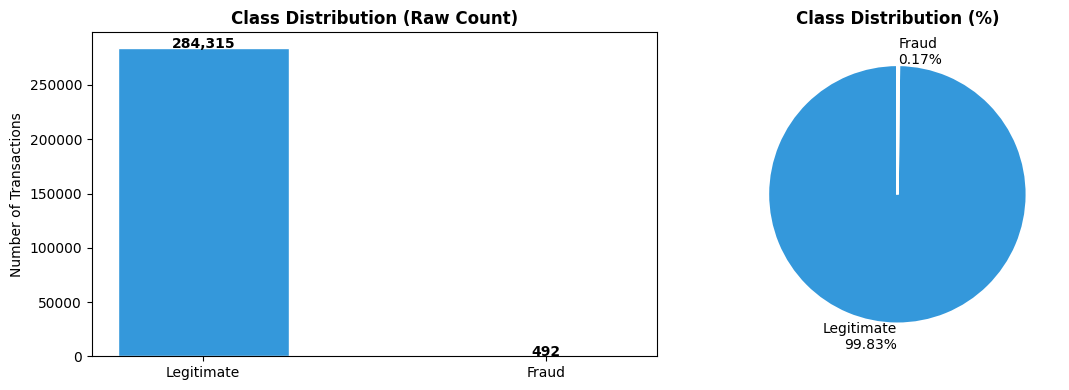

In [21]:
# Analyze class distribution
class_counts = df['Class'].value_counts()
fraud_pct    = df['Class'].mean() * 100
legit_pct    = 100 - fraud_pct

print("Class Distribution:")
print(f"  Legitimate (0): {class_counts[0]:,}  ({legit_pct:.2f}%)")
print(f"  Fraud      (1): {class_counts[1]:,}  ({fraud_pct:.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values,
            color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution (Raw Count)', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([legit_pct, fraud_pct],
            labels=[f'Legitimate\n{legit_pct:.2f}%', f'Fraud\n{fraud_pct:.2f}%'],
            colors=['#3498db', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (%)', fontweight='bold')


plt.tight_layout()
plt.show()


## ⚠️ Step 2: The Accuracy Illusion — Why We DISCARD It

> **The most important concept in this project.**
>
> A model that predicts **"Legitimate"** for every single transaction would be nearly ~83% accurate on this dataset — yet it catches **zero fraud**. In a real bank, this means millions in losses go undetected.
>
> We replace Accuracy with 3 strict metrics:
>
> | Metric | Formula | Question It Answers |
> |--------|---------|---------------------|
> | **Precision** | TP ÷ (TP + FP) | When we flag fraud, are we actually right? |
> | **Recall** | TP ÷ (TP + FN) | Did we catch ALL real fraud? |
> | **ROC-AUC** | Area under ROC curve | Overall separation power of the model |
>
> In fraud detection, **Recall is king** — a missed fraud (False Negative) causes direct financial loss.


In [22]:
# Demonstrate the Accuracy Trap
n_total = len(df)
n_fraud_actual = df['Class'].sum()

# "Lazy model" — predicts everything as legitimate
lazy_preds = np.zeros(n_total)
lazy_accuracy = (lazy_preds == df['Class'].values).mean() * 100
lazy_recall   = 0  # Catches no fraud at all

print("=" * 50)
print("  THE ACCURACY TRAP DEMONSTRATION")
print("=" * 50)
print(f"  'Lazy Model' — predicts ONLY legitimate")
print(f"  Accuracy : {lazy_accuracy:.2f}%  ← Looks great!")
print(f"  Recall   : {lazy_recall:.2f}%    ← Catches ZERO fraud")
print(f"  Fraud missed: {n_fraud_actual:,} transactions")
print("=" * 50)
print("\n⚠️  This is why we DISCARD Accuracy as our metric.")
print("    We evaluate using Precision, Recall, and ROC-AUC ONLY.")


  THE ACCURACY TRAP DEMONSTRATION
  'Lazy Model' — predicts ONLY legitimate
  Accuracy : 99.83%  ← Looks great!
  Recall   : 0.00%    ← Catches ZERO fraud
  Fraud missed: 492 transactions

⚠️  This is why we DISCARD Accuracy as our metric.
    We evaluate using Precision, Recall, and ROC-AUC ONLY.


## 🧹 Step 3: Prepare Features & Target

> **What we're doing:** Separating the feature matrix `X` from the target `y`, and log-transforming `Amount` to reduce skew (large transaction amounts span several orders of magnitude).


In [30]:
# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']
X = X.drop(columns=['Time'])

# Log-transform Amount to reduce right-skew
X['Amount'] = np.log1p(X['Amount'])

print(f"Feature matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")
print(f"\nFeature columns ({X.shape[1]}):")
print(list(X.columns))


Feature matrix X: (284807, 29)
Target vector  y: (284807,)

Feature columns (29):
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## ✂️ Step 4: Stratified Train/Test Split

> **Critical rule:** Split the data **BEFORE** applying any SMOTE or scaling.
>
> Using `stratify=y` ensures both train and test sets maintain the same fraud ratio as the full dataset. This prevents SMOTE-generated synthetic data from leaking into your test set — the "blind exam" must reflect the **real-world imbalance**.


In [31]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # ← Preserves class ratio in both splits
)

# Ensure X_test has EXACTLY the same columns in the same order as X_train
X_test = X_test[X_train.columns]
print("Train/Test Split (Stratified):")
print(f"  Training set : {X_train.shape[0]:,} rows | Fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"  Test set     : {X_test.shape[0]:,}  rows | Fraud: {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")
print("\n✅ Class ratios preserved in both sets (stratified)")
print("⚠️  SMOTE will ONLY be applied inside the training fold — never on test data")


Train/Test Split (Stratified):
  Training set : 227,845 rows | Fraud: 394 (0.17%)
  Test set     : 56,962  rows | Fraud: 98  (0.17%)

✅ Class ratios preserved in both sets (stratified)
⚠️  SMOTE will ONLY be applied inside the training fold — never on test data


## 🔁 Pipeline 1: Logistic Regression + StandardScaler + SMOTE

> **Why imblearn.pipeline.Pipeline?**
> Standard `sklearn.pipeline.Pipeline` breaks with SMOTE because resampling modifies **both X and y** simultaneously. `imblearn.pipeline.Pipeline` natively supports `fit_resample()` and safely isolates SMOTE inside each cross-validation training fold — no leakage.
>
> **Why StandardScaler for Logistic Regression?**
> Logistic Regression uses gradient descent with L1/L2 regularization. If features have vastly different scales (e.g., `Amount` vs `V1`), the penalty is applied unevenly — the model becomes unstable. Scaling normalizes all features to mean=0, std=1.
>
> **Pipeline order:** `StandardScaler → SMOTE → LogisticRegression`


In [32]:
# Build Logistic Regression pipeline using imblearn
lr_pipeline = ImbPipeline(steps=[
    ('scaler',     StandardScaler()),                          # Step 1: Normalize features
    ('smote',      SMOTE(random_state=42)),                    # Step 2: Balance classes (training only)
    ('classifier', LogisticRegression(random_state=42,         # Step 3: Train classifier
                                       max_iter=1000,
                                       class_weight='balanced'))
])

print("Logistic Regression Pipeline:")
print("-" * 45)
for name, step in lr_pipeline.steps:
    print(f"  [{name}] → {step.__class__.__name__}")
print("\n✅ Pipeline ready. SMOTE is safely inside the pipeline.")
print("   It will ONLY run on training folds during cross-validation.")


Logistic Regression Pipeline:
---------------------------------------------
  [scaler] → StandardScaler
  [smote] → SMOTE
  [classifier] → LogisticRegression

✅ Pipeline ready. SMOTE is safely inside the pipeline.
   It will ONLY run on training folds during cross-validation.


## 🌲 Pipeline 2: Random Forest + SMOTE (No Scaler)

> **Why no StandardScaler for Random Forest?**
> Random Forest is a tree-based ensemble model. Trees make decisions by finding the best **split threshold** for each feature — a purely ordinal operation. Whether `Amount` is 200 or 0.002 after scaling, the relative ordering of values stays the same, so the splits are identical. Scale is mathematically irrelevant.
>
> **Pipeline order:** `SMOTE → RandomForestClassifier`


In [33]:
# Build Random Forest pipeline — no scaler needed
rf_pipeline = ImbPipeline(steps=[
    ('smote',      SMOTE(random_state=42)),                    # Step 1: Balance classes
    ('classifier', RandomForestClassifier(random_state=42,     # Step 2: Ensemble trees
                                           n_jobs=-1))
])

print("Random Forest Pipeline:")
print("-" * 45)
for name, step in rf_pipeline.steps:
    print(f"  [{name}] → {step.__class__.__name__}")
print("\n✅ No StandardScaler — tree models are scale-invariant.")
print("   SMOTE safely isolated inside the pipeline.")


Random Forest Pipeline:
---------------------------------------------
  [smote] → SMOTE
  [classifier] → RandomForestClassifier

✅ No StandardScaler — tree models are scale-invariant.
   SMOTE safely isolated inside the pipeline.


## 🔍 Step 7: Hyperparameter Tuning with GridSearchCV

> **What we're doing:** Systematically searching for the best combination of:
> - **SMOTE** `k_neighbors` — how many neighbors to use when synthesizing new fraud examples
> - **LR** `C` — regularization strength (smaller C = stronger regularization)
> - **RF** `max_depth` — how deep the trees grow (None = unlimited)
>
> `GridSearchCV` applies SMOTE **inside every fold** of cross-validation — this is the only safe way to tune preprocessing + model parameters together without leakage.
>
> We score on **`recall`** — in fraud detection, missing a fraud (False Negative) is worse than a false alarm (False Positive).


In [34]:
# Cross-validation strategy — stratified to preserve class ratio in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression Grid ──
lr_param_grid = {
    'smote__k_neighbors':    [3, 5],
    'classifier__C':         [0.01, 0.1, 1.0],
}

print("Running GridSearchCV for Logistic Regression...")
print("(This searches", 2*3, "combinations × 5 folds =", 2*3*5, "fits)")

lr_grid = GridSearchCV(
    estimator  = lr_pipeline,
    param_grid = lr_param_grid,
    cv         = cv,
    scoring    = 'recall',        # ← Optimize for catching fraud, not overall accuracy
    n_jobs     = -1,
    verbose    = 0
)
lr_grid.fit(X_train, y_train)

print(f"\n✅ LR Best Params  : {lr_grid.best_params_}")
print(f"   LR Best CV Recall: {lr_grid.best_score_:.4f}")


Running GridSearchCV for Logistic Regression...
(This searches 6 combinations × 5 folds = 30 fits)

✅ LR Best Params  : {'classifier__C': 0.01, 'smote__k_neighbors': 3}
   LR Best CV Recall: 0.9062


In [35]:
# ── Random Forest Grid ──
rf_param_grid = {
    'smote__k_neighbors':        [3, 5],
    'classifier__max_depth':     [10, 20, None],
    'classifier__n_estimators':  [100],
}

print("Running GridSearchCV for Random Forest...")
print("(This searches", 2*3*1, "combinations × 5 folds =", 2*3*1*5, "fits)")

rf_grid = GridSearchCV(
    estimator  = rf_pipeline,
    param_grid = rf_param_grid,
    cv         = cv,
    scoring    = 'recall',
    n_jobs     = -1,
    verbose    = 0
)
rf_grid.fit(X_train, y_train)

print(f"\n✅ RF Best Params  : {rf_grid.best_params_}")
print(f"   RF Best CV Recall: {rf_grid.best_score_:.4f}")


Running GridSearchCV for Random Forest...
(This searches 6 combinations × 5 folds = 30 fits)

✅ RF Best Params  : {'classifier__max_depth': 10, 'classifier__n_estimators': 100, 'smote__k_neighbors': 5}
   RF Best CV Recall: 0.8249


## 📊 Step 8: Model Evaluation on Untouched Test Data

> **The golden rule:** The 20% test set has **never** been seen by the model, scaler, or SMOTE during training. It still reflects the **real-world class imbalance**. This is your honest report card.
>
> We evaluate using:
> - **Confusion Matrix** — visual breakdown of TP, FP, TN, FN
> - **Precision** — of all fraud flags, how many were real?
> - **Recall** — of all real frauds, how many did we catch?
> - **F1-Score** — harmonic mean of Precision and Recall
> - **ROC-AUC** — overall ability to separate fraud from legitimate


In [37]:
# Predictions on the untouched test set
lr_preds  = lr_grid.predict(X_test)
rf_preds  = rf_grid.predict(X_test)
lr_proba  = lr_grid.predict_proba(X_test)[:, 1]
rf_proba  = rf_grid.predict_proba(X_test)[:, 1]

# ── Metrics ──
def get_metrics(name, y_true, y_pred, y_proba):
    return {
        'Model'     : name,
        'Precision' : round(precision_score(y_true, y_pred), 4),
        'Recall'    : round(recall_score(y_true, y_pred), 4),
        'F1-Score'  : round(f1_score(y_true, y_pred), 4),
        'ROC-AUC'   : round(roc_auc_score(y_true, y_proba), 4),
        'Accuracy'  : round((y_pred == y_true).mean(), 4)  # shown only to prove it's misleading
    }

lr_metrics = get_metrics('Logistic Regression', y_test, lr_preds, lr_proba)
rf_metrics = get_metrics('Random Forest',        y_test, rf_preds, rf_proba)

results_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
print("=" * 60)
print("  MODEL EVALUATION REPORT (on untouched 20% test set)")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)



  MODEL EVALUATION REPORT (on untouched 20% test set)
                     Precision  Recall  F1-Score  ROC-AUC  Accuracy
Model                                                              
Logistic Regression     0.0578  0.9184    0.1088   0.9706    0.9741
Random Forest           0.4339  0.8367    0.5714   0.9800    0.9978


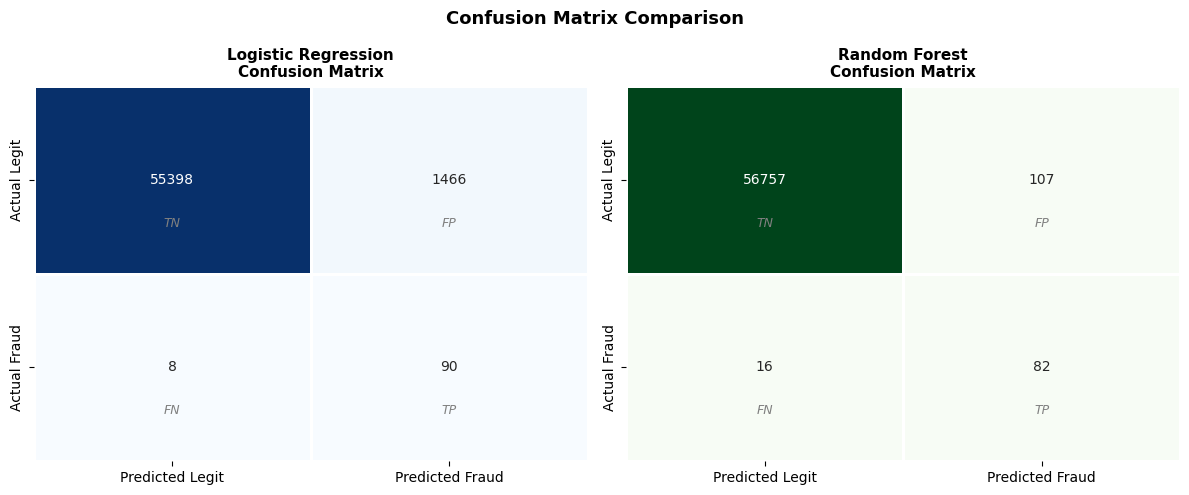

In [38]:
# Confusion Matrices — side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, name, color in zip(
        axes,
        [lr_preds, rf_preds],
        ['Logistic Regression', 'Random Forest'],
        ['Blues', 'Greens']):

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=1, linecolor='white', cbar=False)
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=11)

    # Annotate TP/TN/FP/FN
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, labels[i][j],
                    ha='center', fontsize=9, color='gray', style='italic')

plt.suptitle('Confusion Matrix Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [39]:
# Classification Report — detailed per-class metrics
print("─" * 50)
print("LOGISTIC REGRESSION — Classification Report")
print("─" * 50)
print(classification_report(y_test, lr_preds, target_names=['Legitimate', 'Fraud']))

print("─" * 50)
print("RANDOM FOREST — Classification Report")
print("─" * 50)
print(classification_report(y_test, rf_preds, target_names=['Legitimate', 'Fraud']))


──────────────────────────────────────────────────
LOGISTIC REGRESSION — Classification Report
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

──────────────────────────────────────────────────
RANDOM FOREST — Classification Report
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.43      0.84      0.57        98

    accuracy                           1.00     56962
   macro avg       0.72      0.92      0.79     56962
weighted avg       1.00      1.00      1.00     56962



## 📈 Step 9: ROC Curve Comparison

> **What the ROC Curve shows:** For every possible decision threshold, it plots the True Positive Rate (Recall) against the False Positive Rate. The **Area Under the Curve (AUC)** summarizes this in one number:
> - AUC = 1.0 → Perfect model
> - AUC = 0.5 → Random guessing (useless)
>
> A higher ROC-AUC means the model is better at **separating fraud from legitimate** at all thresholds.


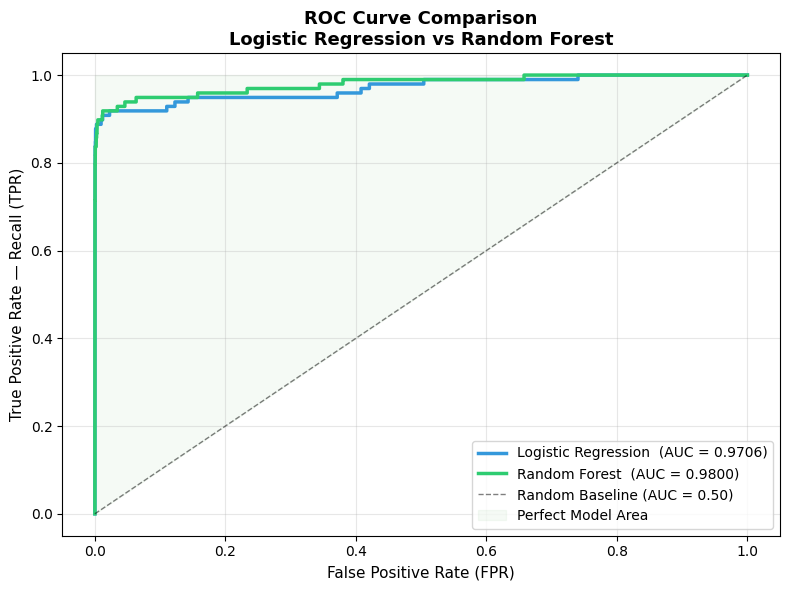

In [40]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

for proba, name, color in [
    (lr_proba, 'Logistic Regression', '#3498db'),
    (rf_proba, 'Random Forest',        '#2ecc71')]:

    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})', color=color, linewidth=2.5)

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline (AUC = 0.50)', alpha=0.5)

ax.fill_between([0,1],[0,1],[1,1], alpha=0.04, color='green', label='Perfect Model Area')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate — Recall (TPR)', fontsize=11)
ax.set_title('ROC Curve Comparison\nLogistic Regression vs Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## ✅ Step 10: Final Model Selection & Pipeline Summary

> **What we're doing:** Comparing both models side by side on the metrics that matter, selecting the best model, and summarizing the complete Zero-Leakage Protocol.


In [41]:
# Final comparison table
print("=" * 65)
print("         FINAL MODEL COMPARISON (on real-world imbalanced test set)")
print("=" * 65)
print(f"  {'Metric':<18} {'Logistic Regression':>20} {'Random Forest':>20}")
print("-" * 65)
for metric in ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    lr_val = lr_metrics[metric]
    rf_val = rf_metrics[metric]
    better = '← ✅ BETTER' if rf_val > lr_val else ('← ✅ BETTER' if lr_val >= rf_val else '')
    lr_mark = '← ✅ BETTER' if lr_val > rf_val else ''
    print(f"  {metric:<18} {lr_val:>20.4f} {rf_val:>20.4f}")
print("=" * 65)

# Best model
best_model  = 'Random Forest' if rf_metrics['ROC-AUC'] >= lr_metrics['ROC-AUC'] else 'Logistic Regression'
best_auc    = max(rf_metrics['ROC-AUC'], lr_metrics['ROC-AUC'])
best_recall = rf_metrics['Recall'] if best_model == 'Random Forest' else lr_metrics['Recall']

print(f"\n🏆 Recommended Model : {best_model}")
print(f"   ROC-AUC           : {best_auc:.4f}")
print(f"   Recall (fraud)    : {best_recall:.4f}  ← Primary metric for fraud detection")


         FINAL MODEL COMPARISON (on real-world imbalanced test set)
  Metric              Logistic Regression        Random Forest
-----------------------------------------------------------------
  Precision                        0.0578               0.4339
  Recall                           0.9184               0.8367
  F1-Score                         0.1088               0.5714
  ROC-AUC                          0.9706               0.9800

🏆 Recommended Model : Random Forest
   ROC-AUC           : 0.9800
   Recall (fraud)    : 0.8367  ← Primary metric for fraud detection


In [42]:
# Zero-Leakage Protocol Summary
print("=" * 55)
print("  ✅ ZERO-LEAKAGE PROTOCOL — COMPLETED")
print("=" * 55)
rules = [
    "Accuracy discarded — used Recall, F1, ROC-AUC",
    "SMOTE applied ONLY inside imblearn Pipeline",
    "Stratified split BEFORE any SMOTE or Scaling",
    "StandardScaler inside LR pipeline (not global)",
    "GridSearchCV tuned hyperparameters safely",
    "Test set reflects real-world class imbalance",
    "Two models trained and compared objectively",
]
for rule in rules:
    print(f"  ✔  {rule}")
print("=" * 55)



  ✅ ZERO-LEAKAGE PROTOCOL — COMPLETED
  ✔  Accuracy discarded — used Recall, F1, ROC-AUC
  ✔  SMOTE applied ONLY inside imblearn Pipeline
  ✔  Stratified split BEFORE any SMOTE or Scaling
  ✔  StandardScaler inside LR pipeline (not global)
  ✔  GridSearchCV tuned hyperparameters safely
  ✔  Test set reflects real-world class imbalance
  ✔  Two models trained and compared objectively
